# From Citywide Inventory to a Daily Route

**Author:** Jennifer Zhang  
**Mapping Systems — Assignment 02: Geoprocessing**

**Daily-life narrative:** A privacy-preserving mental map connects my generalized Columbia weekday routine: arriving at 116 St, moving to Fayerweather Hall, studying at Butler Library, and taking an outdoor break at Morningside Park.

**Spatial question:** Where does this generalized routine pass near a recorded public Wi-Fi location, and where along the route is the nearest listed hotspot farther away?

The personal route and the citywide Wi-Fi inventory have compatible spatial roles: a LineString supports corridor analysis, while route stops and hotspot records support point-to-point nearest joins.

## Required submission components

This folder sits inside the repository's `content/Assignments/` directory and contains every item requested in the brief:

| Brief requirement | Submitted item |
|---|---|
| Daily-life dataset in GeoJSON format | `daily_study_loop.geojson` |
| Proposed related dataset | [NYC Wi-Fi Hotspot Locations](https://data.cityofnewyork.us/d/yjub-udmw) |
| Markdown with the related-dataset link | `README.md` |
| Proposed methodology | `README.md` and Sections 3–10 below |
| Workflow expressed as a diagram | `workflow.svg` |

The executed analysis below is supporting evidence that the proposed relationship is feasible; it does not replace those required files.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from analyze_route import (
    ANALYSIS_CRS,
    BUFFER_M,
    OUTPUT_CRS,
    SAMPLE_INTERVAL_M,
    create_context_map,
    create_summary_figure,
    load_inputs,
    process_inputs,
    write_outputs,
)

pd.set_option("display.max_columns", 30)

## 1. Personal dataset: a mixed-geometry mental map

The personal GeoJSON deliberately contains two geometry roles:

- One **LineString** represents generalized movement.
- Four **Points** represent named public stops that can be nearest-joined to another point dataset.

Every feature has a stable ID, a narrative role, and a privacy label. The data are authored at public-place precision rather than extracted from private location history.

In [2]:
route_all, wifi = load_inputs()

print(f"Personal features: {len(route_all)}")
print(f"Personal CRS: {route_all.crs}")
print("Geometry types:")
display(route_all.geometry.geom_type.value_counts().rename_axis("geometry_type").to_frame("features"))

display(
    route_all[
        ["feature_id", "name", "feature_type", "sequence", "activity", "narrative", "privacy_level"]
    ].sort_values("sequence")
)

Personal features: 5
Personal CRS: EPSG:4326
Geometry types:


,features
geometry_type,
Point,4
LineString,1


,feature_id,name,feature_type,sequence,activity,narrative,privacy_level
0,route-01,Generalized weekday study route,route,0,None,A privacy-preserving mental map connecting pub...,generalized public-place route
1,stop-01,116 St–Columbia University subway entrance,stop,1,arrival / departure,Transit access anchors the west end of the route.,public place
2,stop-02,Fayerweather Hall,stop,2,studio / class,The route's primary daytime destination.,public institutional place
3,stop-03,Butler Library,stop,3,study,A second indoor work location along the routine.,public institutional place
4,stop-04,Morningside Park west entrance,stop,4,outdoor break,The park edge marks a shift from campus interi...,public place


The route contains no home address, exact timestamps, or private destinations. Its purpose is to express a mental image of a routine—transit, studio, library, and park edge—while leaving the geometry suitable for spatial operations.

## 2. Proposed related dataset: NYC public Wi-Fi

The proposed related dataset is [NYC Wi-Fi Hotspot Locations](https://data.cityofnewyork.us/d/yjub-udmw), a citywide Point inventory published through NYC Open Data. A cleaned 3,319-point local copy is included at `related_data/nyc_wifi_hotspots_clean.geojson` so the analysis can be reproduced from this folder.

The relationship is useful because the personal dataset contains a route and stops, while the related dataset contains Points with `type`, `provider`, and `location_t`. This supports corridor intersection, point-to-point nearest joins, and a distance profile.

In [3]:
print(f"Related NYC Wi-Fi records: {len(wifi):,}")
print(f"Related CRS: {wifi.crs}")

wifi_metadata = pd.DataFrame(
    {
        "meaning": {
            "objectid": "Unique published inventory record identifier",
            "type": "Published access category",
            "provider": "Published operator/provider",
            "location_t": "Published site context",
            "geometry": "Recorded point location",
        },
        "role_in_02": {
            "objectid": "Preserve traceability after joins",
            "type": "Compare local corridor with citywide composition",
            "provider": "Distinguish nearby records on the map",
            "location_t": "Describe what kind of place the nearest record represents",
            "geometry": "Intersect the route buffer and measure nearest distance",
        },
    }
)
display(wifi_metadata)
display(wifi["type"].value_counts().rename_axis("access_type").to_frame("records"))

Related NYC Wi-Fi records: 3,319
Related CRS: EPSG:4326


,meaning,role_in_02
objectid,Unique published inventory record identifier,Preserve traceability after joins
type,Published access category,Compare local corridor with citywide composition
provider,Published operator/provider,Distinguish nearby records on the map
location_t,Published site context,Describe what kind of place the nearest record...
geometry,Recorded point location,Intersect the route buffer and measure nearest...


,records
access_type,
Free,2736
Limited Free,581
Partner Site,2


## 3. Proposed workflow diagram

![Workflow diagram showing the personal route and NYC public Wi-Fi data being validated, projected, buffered, spatially intersected, nearest-joined, sampled, and exported](workflow.svg)

The workflow creates three different spatial relationships:

1. **Point-to-buffer intersection:** Which Wi-Fi records fall inside 250 m of the route?
2. **Point-to-point nearest neighbor:** Which record is nearest to each named stop?
3. **Point samples along a line:** How does nearest-record distance change continuously along the generalized route?

## 4. Project before measuring

The source layers use longitude/latitude (`EPSG:4326`). Degrees are not a suitable unit for a 250 m buffer or local distance measurement, so every metric operation is performed in **NAD83 / New York Long Island (`EPSG:2263`)**.

`EPSG:2263` uses US survey feet. The pipeline explicitly converts the 250 m threshold and reports final distances in metres. Outputs are converted back to `EPSG:4326` for GitHub and web-map compatibility.

In [4]:
result = process_inputs(route_all, wifi, buffer_m=BUFFER_M)

route_length_m = result["route_projected"].geometry.iloc[0].length / 3.28084
nearby = result["nearby_projected"]
enriched_stops = result["enriched_stops_projected"]
samples = result["route_samples_projected"]

print(f"Analysis CRS: {ANALYSIS_CRS}")
print(f"Output CRS: {OUTPUT_CRS}")
print(f"Generalized route length: {route_length_m:,.1f} m")
print(f"Route buffer: {BUFFER_M:.0f} m")
print(f"Route sampling interval: {SAMPLE_INTERVAL_M:.0f} m")

Analysis CRS: EPSG:2263
Output CRS: EPSG:4326
Generalized route length: 1,177.1 m
Route buffer: 250 m
Route sampling interval: 25 m


## 5. Buffer and spatial intersection

The route is buffered by 250 m and the related Wi-Fi Points are spatially filtered with `intersects`. This creates a local corridor subset without pretending the buffer is a radio-signal model.

The threshold is intentionally transparent and adjustable. It supports comparison; it is not evidence that every listed hotspot provides service across a 250 m radius.

In [5]:
print(f"Wi-Fi records intersecting the 250 m route corridor: {len(nearby)}")

print("Access types in corridor:")
display(nearby["type"].value_counts().rename_axis("access_type").to_frame("records"))

print("Providers in corridor:")
display(nearby["provider"].value_counts().rename_axis("provider").to_frame("records"))

display(
    nearby[
        ["objectid", "name", "provider", "type", "location_t", "distance_to_route_m"]
    ].head(10).style.format({"distance_to_route_m": "{:.1f} m"})
)

Wi-Fi records intersecting the 250 m route corridor: 15
Access types in corridor:
Providers in corridor:


,records
access_type,
Free,15


,records
provider,
LinkNYC - Citybridge,11
Transit Wireless,2
NYPL,1
Harlem,1


,objectid,name,provider,type,location_t,distance_to_route_m
3242,11390,116 St-Columbia University (1),Transit Wireless,Free,Subway Station,2.7 m
306,12483,mn-09-137848,LinkNYC - Citybridge,Free,Outdoor Kiosk,30.9 m
2565,12482,mn-09-120262,LinkNYC - Citybridge,Free,Outdoor Kiosk,38.7 m
960,12484,mn-09-120261,LinkNYC - Citybridge,Free,Outdoor Kiosk,56.6 m
1834,12485,mn-09-120387,LinkNYC - Citybridge,Free,Outdoor Kiosk,127.3 m
1357,11296,Morningside Heights,NYPL,Free,Library,147.5 m
1205,12896,mn-09-120546,LinkNYC - Citybridge,Free,Outdoor Kiosk,160.7 m
756,12474,mn-09-120408,LinkNYC - Citybridge,Free,Outdoor Kiosk,179.8 m
3241,11389,"116 St (A, B,C)",Transit Wireless,Free,Subway Station,183.4 m
1450,12783,mn-09-120545,LinkNYC - Citybridge,Free,Outdoor Kiosk,205.0 m


The 250 m corridor contains **15 records**, all published as `Free`: 11 LinkNYC records, 2 Transit Wireless records, 1 NYPL record, and 1 Harlem record. The lack of local `type` variation is itself a result; provider and location context still differ.

This subset cannot establish that all parts of the route receive Wi-Fi. It only says that a recorded Point lies within a geometric distance of the generalized LineString.

## 6. Nearest join and stop-level enrichment

`sjoin_nearest` attaches the nearest Wi-Fi record to each named stop and records projected straight-line distance. A separate 250 m stop buffer counts how many records lie near each stop.

The original Point geometry and personal narrative fields are preserved in the enriched output. Related attributes are added rather than replacing the authored dataset.

In [6]:
stop_table = enriched_stops[
    [
        "name",
        "activity",
        "nearest_wifi_name",
        "nearest_provider",
        "nearest_access_type",
        "nearest_location_type",
        "nearest_distance_m",
        "wifi_records_within_250m",
    ]
].copy()

display(
    stop_table.style.format(
        {
            "nearest_distance_m": "{:.1f} m",
            "wifi_records_within_250m": "{:,.0f}",
        }
    )
)

,name,activity,nearest_wifi_name,nearest_provider,nearest_access_type,nearest_location_type,nearest_distance_m,wifi_records_within_250m
1,116 St–Columbia University subway entrance,arrival / departure,116 St-Columbia University (1),Transit Wireless,Free,Subway Station,8.9 m,7
2,Fayerweather Hall,studio / class,mn-09-120546,LinkNYC - Citybridge,Free,Outdoor Kiosk,160.7 m,3
3,Butler Library,study,116 St-Columbia University (1),Transit Wireless,Free,Subway Station,144.0 m,8
4,Morningside Park west entrance,outdoor break,"116 St (A, B,C)",Transit Wireless,Free,Subway Station,183.4 m,4


The nearest-record distances range from **8.9 m** at the 116 St subway entrance to **183.4 m** at the Morningside Park entrance. Fayerweather Hall and Butler Library are 160.7 m and 144.0 m from their nearest records.

These are Euclidean distances between generalized/recorded coordinates. Building entrances, walls, stairs, street crossings, and pedestrian routes are not modeled.

## 7. Sample the LineString every 25 m

Four stops alone cannot describe the entire route. Sampling the LineString every 25 m creates 49 analysis Points, then nearest-joins each Point to the Wi-Fi inventory. The resulting profile reveals where the route passes through larger gaps between records.

In [7]:
sample_summary = pd.Series(
    {
        "sample_count": len(samples),
        "median_nearest_distance_m": samples["nearest_distance_m"].median(),
        "maximum_nearest_distance_m": samples["nearest_distance_m"].max(),
        "samples_within_250m_pct": samples["within_250m"].mean() * 100,
    },
    name="route_proximity_summary",
)
display(sample_summary.to_frame().style.format("{:.1f}"))

,route_proximity_summary
sample_count,49.0
median_nearest_distance_m,204.2
maximum_nearest_distance_m,404.8
samples_within_250m_pct,71.4


The sampled-route result is more cautious than the four-stop table: the median sample is **204.2 m** from a listed hotspot, the maximum reaches **404.8 m**, and only **71.4%** of samples fall within the 250 m comparison threshold.

This does not prove a connectivity gap. It identifies parts of the authored route where the published point inventory is less proximate and suggests where field verification would be most useful.

## 8. Map the geoprocessing relationships

The map makes each operation visible: the translucent route buffer, intersecting Wi-Fi Points, the generalized LineString, named stops, and dashed stop-to-nearest-record connections. Provider colors distinguish the local records because all 15 share the same published access type.

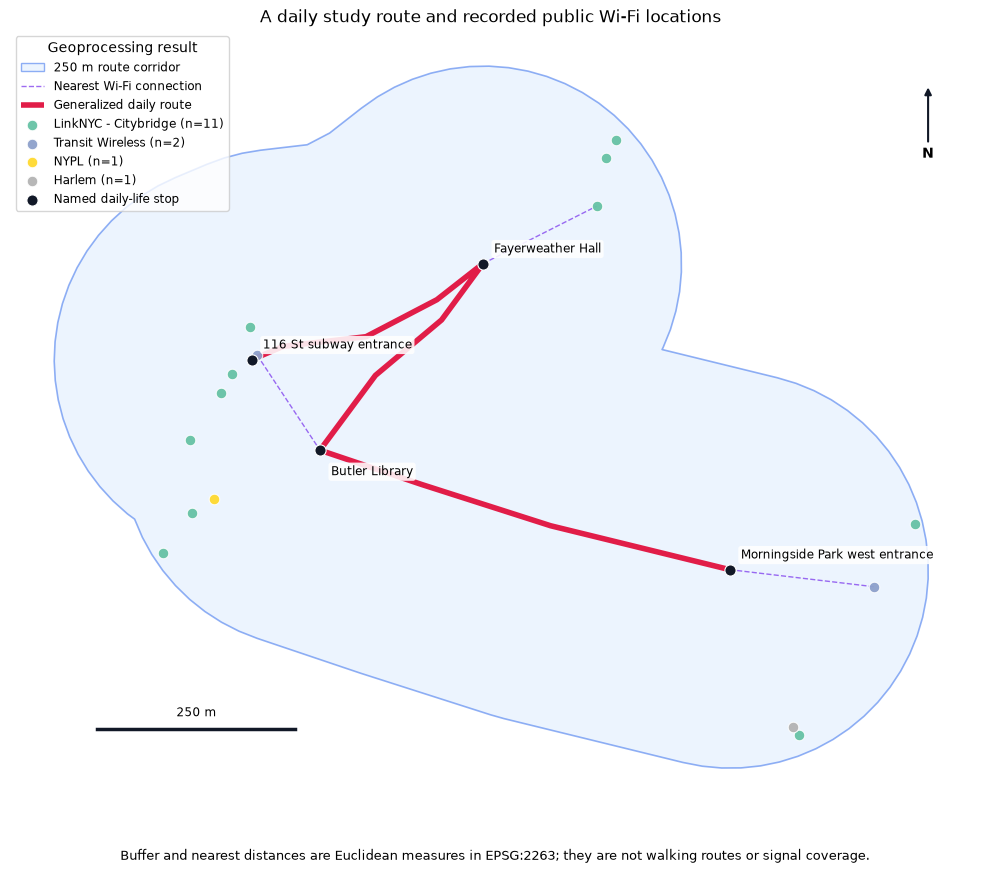

In [8]:
context_map = create_context_map(result)
plt.show()

## 9. Route profile and citywide comparison

The left panel converts the nearest joins for 49 samples into a continuous profile along the route. The right panel compares the complete related dataset's access-type composition with the local corridor subset created by the spatial intersection.

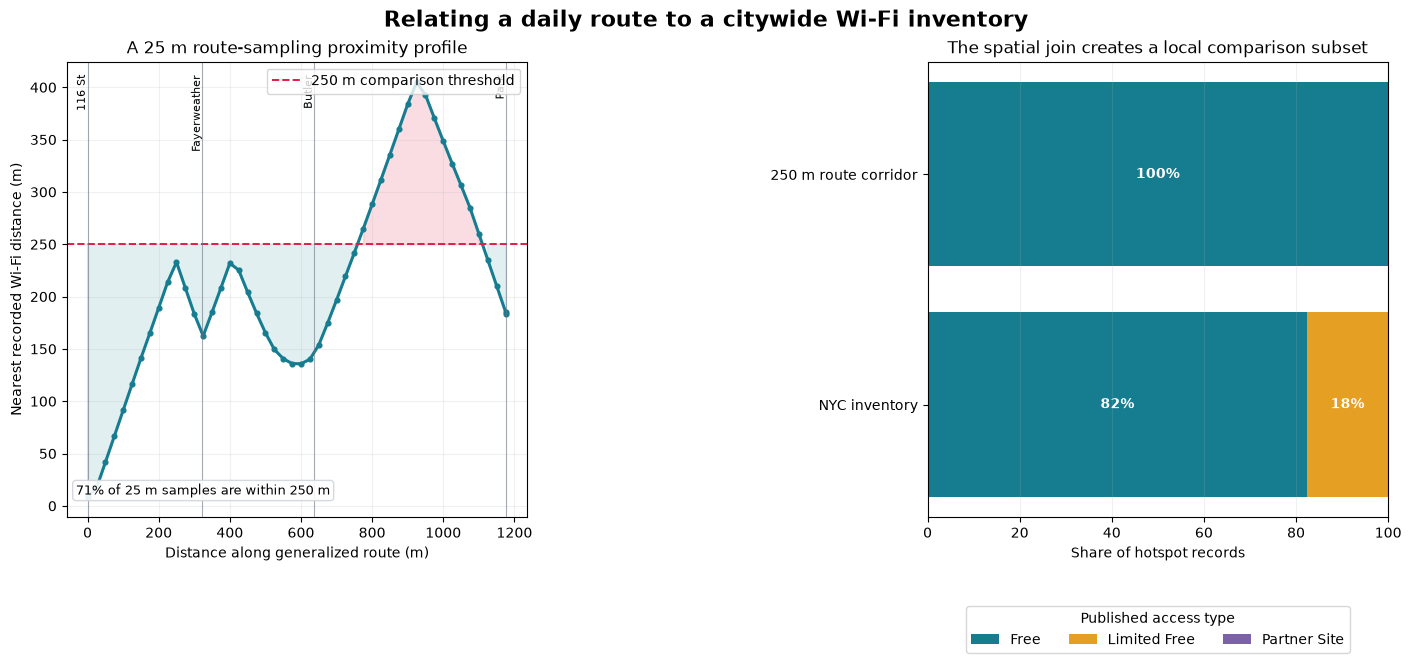

In [9]:
summary_figure = create_summary_figure(result)
plt.show()

## 10. Export and validate

All measurement occurs in the projected CRS, while final GeoJSON is written in `EPSG:4326`. The audit records input counts, join completeness, route length, thresholds, and output row counts so the workflow can be checked without relying only on a screenshot.

In [10]:
audit = write_outputs(result)
display(pd.Series(audit, name="value").to_frame())

required_outputs = [
    "outputs/route_250m_buffer.geojson",
    "outputs/route_wifi_context.geojson",
    "outputs/daily_stops_wifi_enriched.geojson",
    "outputs/nearest_wifi_connections.geojson",
    "outputs/route_proximity_samples.geojson",
    "outputs/geoprocessing_audit.json",
    "outputs/01_route_wifi_geoprocessing_map.png",
    "outputs/02_route_proximity_profile.png",
]
for output in required_outputs:
    path = Path(output)
    assert path.exists() and path.stat().st_size > 0, f"Missing output: {output}"

print("All required and supporting outputs exist.")

All required and supporting outputs exist.


,value
personal_input_features,5
route_features,1
stop_features,4
related_wifi_input_records,3319
analysis_crs,EPSG:2263
output_crs,EPSG:4326
route_buffer_m,250.0
route_length_m,1177.1
wifi_records_intersecting_route_buffer,15
corridor_access_type_counts,{'Free': 15}


## 11. What the relationship can and cannot tell us

### What it can support

- A reproducible 250 m corridor subset from the related point inventory.
- Nearest-record distances and nearby-record counts for four named daily-life stops.
- A 25 m sampled proximity profile along the authored LineString.
- A comparison between citywide and route-corridor published access categories.
- Specific places along the route that merit field verification.

### What it cannot support

- A hotspot Point is not a measured signal radius.
- Straight-line distance is not walking distance, travel time, or indoor accessibility.
- The inventory does not measure speed, uptime, congestion, login requirements, or current operation.
- The generalized route is a personal mental map, not exact GPS history or a representative student sample.
- Proximity does not mean the route caused infrastructure placement or that a user can connect.

The defensible conclusion is that geoprocessing turns the citywide inventory into a route-specific **proximity context**. It does not turn the inventory into proof of service coverage.